# Project Overview

# Guatemala Dengue Surveillance Analysis (2012-2024)

# Research question
How did reported dengue cases change across Guatemala between 2012 and 2024, and what temporal and geographic patterns can be identified using descriptive statistics and statistical inference?

# General Objective
Analyze temporal and geographic patterns of reported dengue cases in Guatemala between 2012 and 2024 using descriptive statistics and statistical methods.
# Specific Objectives
- Identify municipalities with the highest reported number of dengue cases.
- Quantify variability among municipalities.
- Identify municipalities contributing the largest burden.

# Data Sources
## Dataset description table

| Dataset | Description | Unit of Observation |
|----------|-------------|---------------------|
| municipality | Total reported dengue cases aggregated by municipality for the study period. | One municipality |
| year | Total reported dengue cases in Guatemala by calendar year. | One year |
| year_municipality | Reported dengue cases for each municipality in each year. | One municipality during one year |

## Introduction
This notebook analyzes reported dengue cases in Guatemala from 2012 to 2024. The dataset contains information aggregated by year, municipality, and department. The data were obtained from the Ministerio de Salud Pública y Asistencia Social (MSPAS), Guatemala's national public health authority. The objective of this analysis is to explore temporal trends and the geographic distribution of dengue cases across the country.

## Import Libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt 

## Load Data

In [23]:
municipality = pd.read_csv('../exports/dengue_municipality.csv')
year_municipality = pd.read_csv('../exports/dengue_year_municipality.csv')
year_totals = pd.read_csv('../exports/dengue_year_totals.csv')


# Data Inspection
## 5.1 Dataset dimensions

In [24]:
print("Municipality dataset:", municipality.shape)
print("Year dataset:", year_totals.shape)
print("Municipality-Year dataset:", year_municipality.shape)

Municipality dataset: (325, 3)
Year dataset: (13, 2)
Municipality-Year dataset: (2810, 3)



- In Municipality dataset, each row represents a municipality and the total number of cases from 2012-2024.
- In Year dataset, each row represents a year and the number of cases per year.
- In Municipality_Year dataset, each row represents a municipality and the number of cases break down per year. 
- The number of rows differt among...

The municipality-year dataset contains fewer observations than the theoretical maximum of 4,255 municipality-year combinations (325 municipalities x 13 years). This suggests that not every municipality has a record for every year. In this section, we will investigate whether these absent observations represent years with zero reported cases, missing data, or another extraction process issue. 

## 5.2 Data Types

In [25]:
municipality.info()
year_totals.info()
year_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   municipality  325 non-null    str  
 1   department    325 non-null    str  
 2   total_cases   325 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   year         13 non-null     int64
 1   total_cases  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          2810 non-null   int64
 1   municipality  2810 non-null   str  
 2   total_cases   2810 non-null   int64
dtypes: int64(2), str(1)
memory usage: 66.0 KB


The variables in the dataframes that represent year and cases are correctly stored as integers, allowing statistical analysis. On the other hand, the variables for municipalities are stored as text because they are categorical identifiers rather than numerical measurements. Based on this audit, all variables are stored using appropiate data types. 

# 5.3 Missing Values

In [26]:
def summarize_missing_values(df, dataset_name):
    summary = pd.DataFrame({
        "dataset": dataset_name,
        "variable": df.columns,
        "missing_values": df.isna().sum().values,
        "missing_percentage": (
            df.isna().mean().values * 100
        ).round(2)
    })

    return summary

In [27]:
missing_municipality = summarize_missing_values(municipality, "municipality")
missing_year_totals = summarize_missing_values(year_totals, "year_totals")
missing_year_municipality = summarize_missing_values(year_municipality, "year_municipality")

missing_summary = pd.concat(
    [missing_municipality, missing_year_totals, missing_year_municipality],
    ignore_index=True
)

missing_summary 

,dataset,variable,missing_values,missing_percentage
0,municipality,municipality,0,0.0
1,municipality,department,0,0.0
2,municipality,total_cases,0,0.0
3,year_totals,year,0,0.0
4,year_totals,total_cases,0,0.0
5,year_municipality,year,0,0.0
6,year_municipality,municipality,0,0.0
7,year_municipality,total_cases,0,0.0


Missing values were evaluated for every variable in the three datasets to identify incomplete records. No missing values were identified. Therefore, there is no need for changes before proceeding with exploratory and statistical analysis.

# 5.4 Duplicate records

In [28]:
municipality.duplicated(subset=['municipality']).sum()
year_totals.duplicated(subset=['year']).sum()
year_municipality.duplicated(subset=['year', 'municipality']).sum()

np.int64(0)

No duplicates records were identified in the datasets. Therefore, each observation appears to be uniquely represented.

# 5.5 Descriptive Statistics 

In [37]:
municipality["total_cases"].describe()

count      325.000000
mean      1122.092308
std       2515.694928
min          1.000000
25%         56.000000
50%        404.000000
75%       1083.000000
max      22599.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution, probably due to few municipalities contributing more cases than others. 

In [38]:
year_totals["total_cases"].describe()


count        13.000000
mean      28052.307692
std       39734.359471
min        2918.000000
25%        7523.000000
50%       10296.000000
75%       19735.000000
max      141478.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution. This could indicate that some years have peaks in cases than others.

In [39]:
year_municipality["total_cases"].describe()

count    2810.000000
mean      129.779359
std       455.714888
min         1.000000
25%         4.000000
50%        18.000000
75%        78.000000
max      8922.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution, with few municipalities contributing large amount of cases in certain years.

# Distribution Analysis

## Histogram Analysis

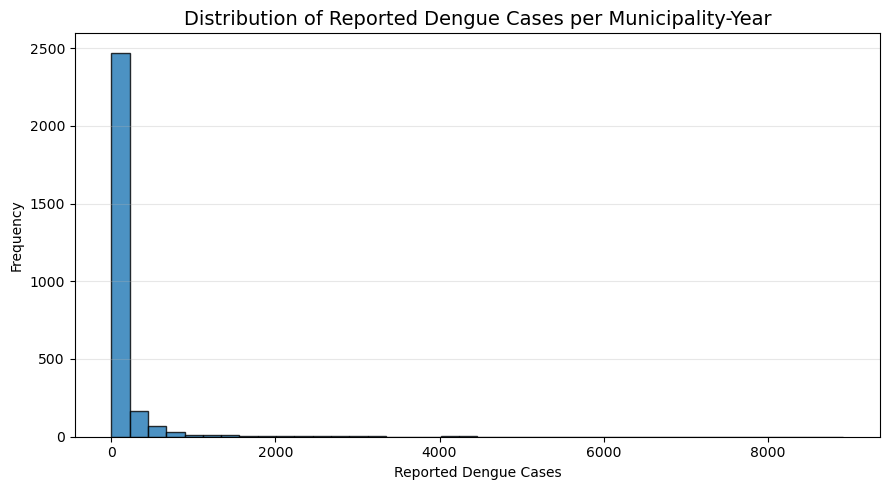

In [41]:
plt.figure(figsize=(9, 5))

plt.hist(
    year_municipality["total_cases"],
    bins=40,
    edgecolor='black',
    alpha=0.8
)

plt.title("Distribution of Reported Dengue Cases per Municipality-Year", fontsize=14)
plt.xlabel("Reported Dengue Cases")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Dengue case counts are highly concentrated at low values, while a relatively small number of municipality-year observations contribute to large outbreaks, producing a strongly right-skewed distribution.

## Boxplot Analysis

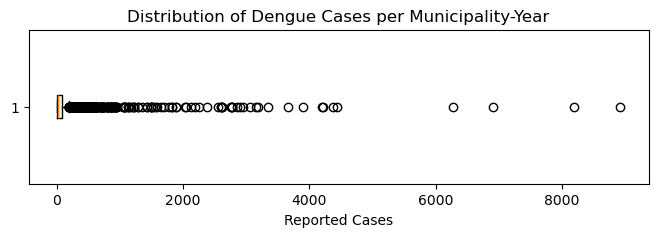

In [42]:
plt.figure(figsize=(8, 2))

plt.boxplot(year_municipality["total_cases"], vert=False)

plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

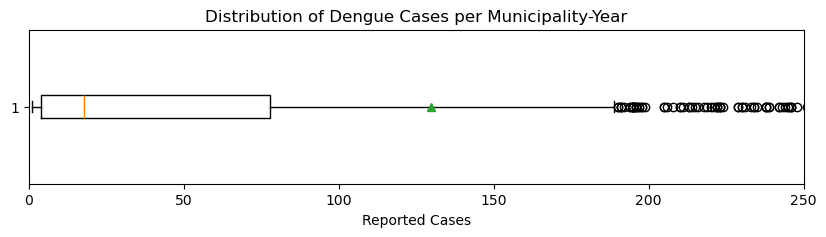

In [44]:
plt.figure(figsize=(10, 2))

plt.boxplot(year_municipality["total_cases"], vert=False, showmeans=True)

plt.xlim(0, 250)   # Zoom in
plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

The boxplot reinforces the findings from the histogram and descriptive statistics. The distribution of dengue cases per municipality-year is strongly right-skewed, with the middle 50% of observations ranging from 4 to 78 reported cases. The large number of observations beyond the upper fence (189 cases) indicates that unusually large outbreaks occurred across multiple municipality-years. These observations should be investigated further, as they may represent true epidemic events rather than data errors.

# Pareto Distribution

In [49]:
pareto_df = municipality.sort_values(by="total_cases", ascending=False).reset_index(drop=True)
pareto_df["cumulative_cases"] = pareto_df["total_cases"].cumsum()
total_cases = pareto_df["total_cases"].sum()
pareto_df["cumulative_%"] = (pareto_df["cumulative_cases"]/total_cases) * 100
pareto_df.head(10)

,municipality,department,total_cases,cumulative_cases,cumulative_%
0,COATEPEQUE,QUETZALTENANGO,22599,22599,6.196940
1,GUATEMALA,GUATEMALA,20709,43308,11.875617
2,MIXCO,GUATEMALA,16607,59915,16.429472
3,JUTIAPA,JUTIAPA,15519,75434,20.684984
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088,86522,23.725458
5,ESCUINTLA,ESCUINTLA,9488,96010,26.327191
6,ZACAPA,ZACAPA,8034,104044,28.530218
7,AMATITLÁN,GUATEMALA,7768,111812,30.660305
8,POPTÚN,EL PETEN,7064,118876,32.597346
9,SALAMÁ,BAJA VERAPAZ,7009,125885,34.519305


## Pareto Graph

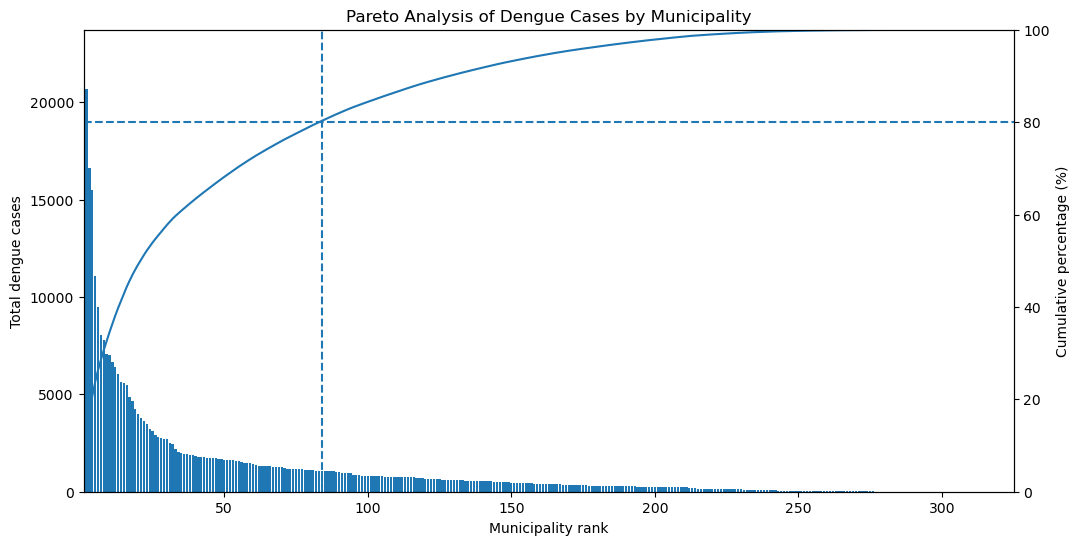

In [65]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    x=range(1, len(pareto_df) + 1),
    height=pareto_df["total_cases"]
)
ax1.set_xlabel("Municipality rank")
ax1.set_ylabel("Total dengue cases")
ax1.set_title(
    "Pareto Analysis of Dengue Cases by Municipality"
)
ax1.set_xlim(1, len(pareto_df))

ax2 = ax1.twinx()
ax2.plot(
    range(1, len(pareto_df) + 1),
    pareto_df["cumulative_%"]
)
ax2.set_ylabel("Cumulative percentage (%)")
ax2.set_ylim(0, 100)

ax2.axhline(
    y=80,
    linestyle="--"
)

threshold_row = pareto_df[
    pareto_df["cumulative_%"] >= 80
].iloc[0]

threshold_rank = threshold_row.name + 1

ax1.axvline(
    x=threshold_rank,
    linestyle="--"
)

In [69]:
municipality_percentage = (threshold_rank / len(pareto_df)) * 100
print(f"Approximately {municipality_percentage:.2f}% of municipalities account for 80% of the total dengue cases.")

Approximately 25.85% of municipalities account for 80% of the total dengue cases.


# Section 10 - Time Analysis

How has the burden of dengue changed over time in Guatemala (2012-2024)?

## YoY Change (%)

In [78]:
year_totals["case difference"] = year_totals["total_cases"].diff()
year_totals["percent_change"] = year_totals["total_cases"].pct_change() * 100

In [80]:
year_totals

,year,total_cases,case difference,percent_change
0,2012,10296,NaN,NaN
1,2013,12833,2537.0,24.640637
2,2014,19735,6902.0,53.783215
3,2015,18612,-1123.0,-5.690398
4,2016,9016,-9596.0,-51.558135
5,2017,4213,-4803.0,-53.271961
6,2018,7523,3310.0,78.566342
7,2019,50597,43074.0,572.564137
8,2020,6011,-44586.0,-88.119849
9,2021,2918,-3093.0,-51.455665


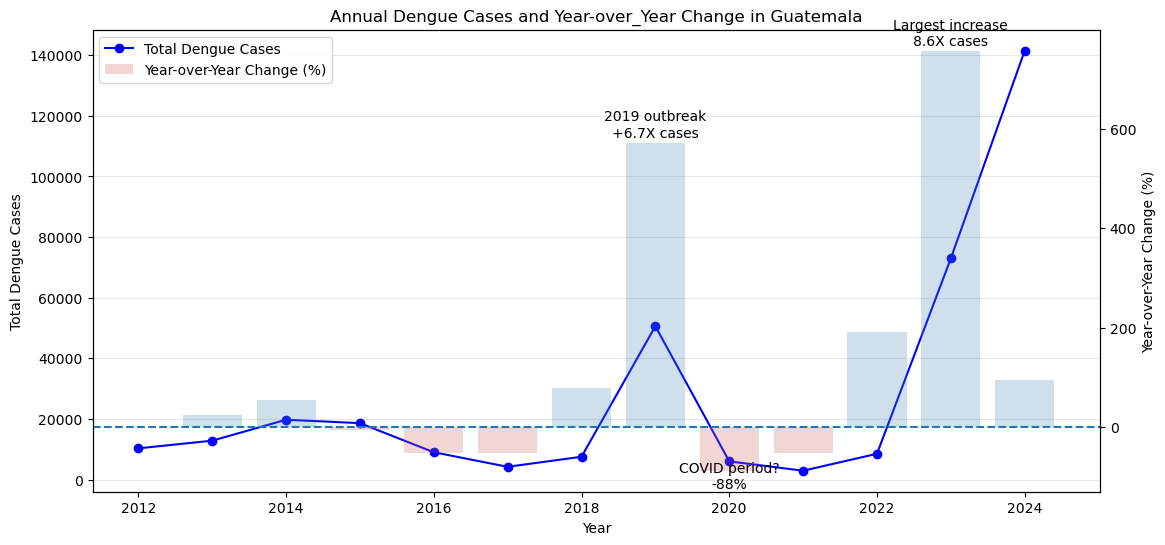

In [125]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(
    year_totals["year"],
    year_totals["total_cases"],
    marker='o',
    label="Total Dengue Cases",
    color='blue'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Dengue Cases")
ax1.set_title("Annual Dengue Cases and Year-over_Year Change in Guatemala")

ax1.grid(
    axis="y",
    alpha=0.3
)

bar_colors = [
    "steelblue" if value >= 0 else "indianred"
    for value in year_totals["percent_change"]
]

ax2 = ax1.twinx()


ax2.bar(
    year_totals["year"],
    year_totals["percent_change"],
    color=bar_colors,
    alpha=0.25,
    label="Year-over-Year Change (%)",
)

ax2.set_ylabel("Year-over-Year Change (%)")
ax2.axhline(
    y=0,
    linestyle="--",
)  

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

annotations = {
    2019: "2019 outbreak\n+6.7X cases",
    2020: "COVID period?\n-88%",
    2023: "Largest increase\n8.6X cases"
}

for year, label in annotations.items():

    year_data = year_totals[
        year_totals["year"] == year
    ].iloc[0]

    x_coordinate = year_data["year"]
    y_coordinate = year_data["percent_change"]

    if year == 2020:
        offset = (0, -13)
    else:
        offset = (0, 4)

    ax2.annotate(
        label,
        xy=(x_coordinate, y_coordinate),
        xytext=offset,
        textcoords="offset points",
        ha="center"
    )



Reported dengue cases remained relatively moderate from 2012 through 2018, despite year-to-year fluctuations. In 2019, Guatemala experienced a major outbreak, with reported cases increasing to approximately 6.7 times compared with the previous year. This was followed by a steep decline in 2020. After a short recovery period, another major outbreak occurred in 2023, producing the largest year-over-year percentage increase (8.6 times the previous year's reported cases). Reported cases then reached their highest absolute total in 2024. These major fluctuations may reflect epidemic dynamics, changes in surveillance or reporting, or disruptions associated with the COVID-19 period. Further investigation using additional epidemiological and contextual data is therefore necessary.

# Chapter 2: Spatial Analysis (Municipalities)

## Municipalities with the highest percentage of burden (2012-2024)
Which municipalities contributed the greatest dengue burden?

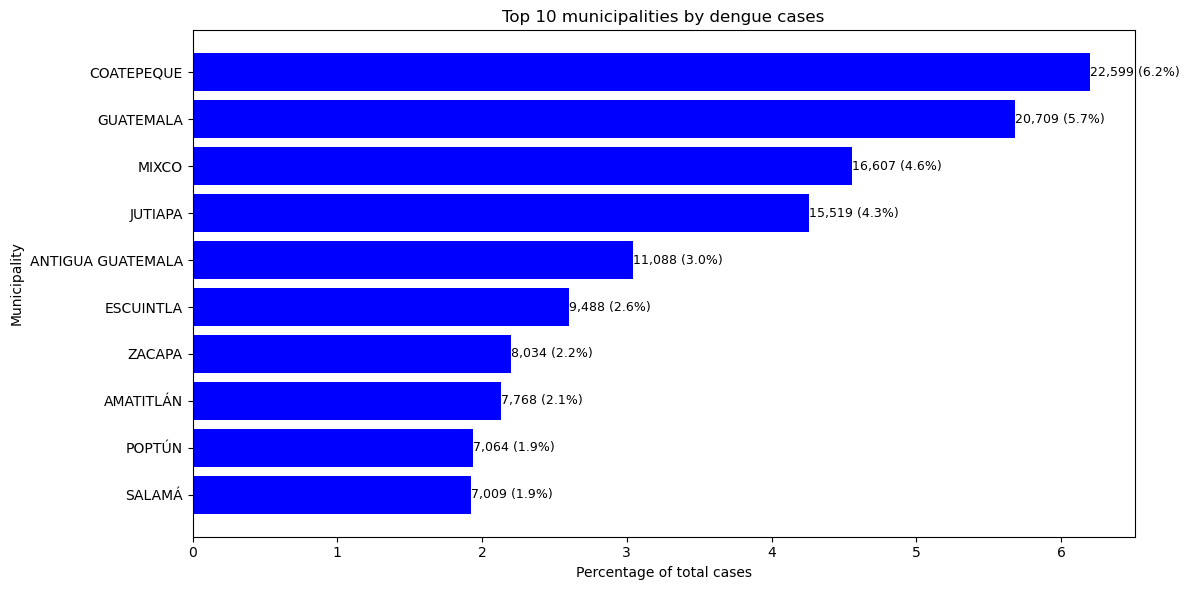

In [ ]:
municipality_top_10 = municipality.sort_values(by="total_cases", ascending=False).head(10)
municipality_top_10["percentage_of_cases"] = (
    municipality_top_10["total_cases"] / municipality["total_cases"].sum()
) * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(
    municipality_top_10["municipality"],
    municipality_top_10["percentage_of_cases"],
    color="blue"
)

for bar, cases, pct in zip(
    bars,
    municipality_top_10["total_cases"],
    municipality_top_10["percentage_of_cases"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{cases:,} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=9
    )

plt.gca().invert_yaxis()
plt.xlabel("Share of national reporte dengue cases (%)")
plt.ylabel("Municipality")
plt.title("Top 10 municipalities by Cumulative Reported Dengue Cases, 2012-2024")
plt.tight_layout()
plt.show()


There does not seem to be one single municipality that overwhelmingly contributes to the national cumulative dengue cases. It is possible that dengue burden is geographically concentrated at the department level, and that will be explored next.

In [143]:
percentage_share_top_10 = municipality_top_10["percentage_of_cases"].sum()
print(f"The top 10 municipalities account for approximately {percentage_share_top_10:.2f}% of the total reported dengue cases in Guatemala from 2012 to 2024.")

The top 10 municipalities account for approximately 34.52% of the total reported dengue cases in Guatemala from 2012 to 2024.


The ten municipalities with the highest cumulative dengue burden accounted for approximately 34.5% of all reported dengue cases in Guatemala between 2012 and 2024. Although no individual municipality contributed more than 6.2% of the national total, a small group of municipalities accounted for more than one-third of all reported cases. This suggests that dengue burden is geographically concentrated rather than evenly distributed across municipalities.

## Annual Trend Analysis 2012-2024

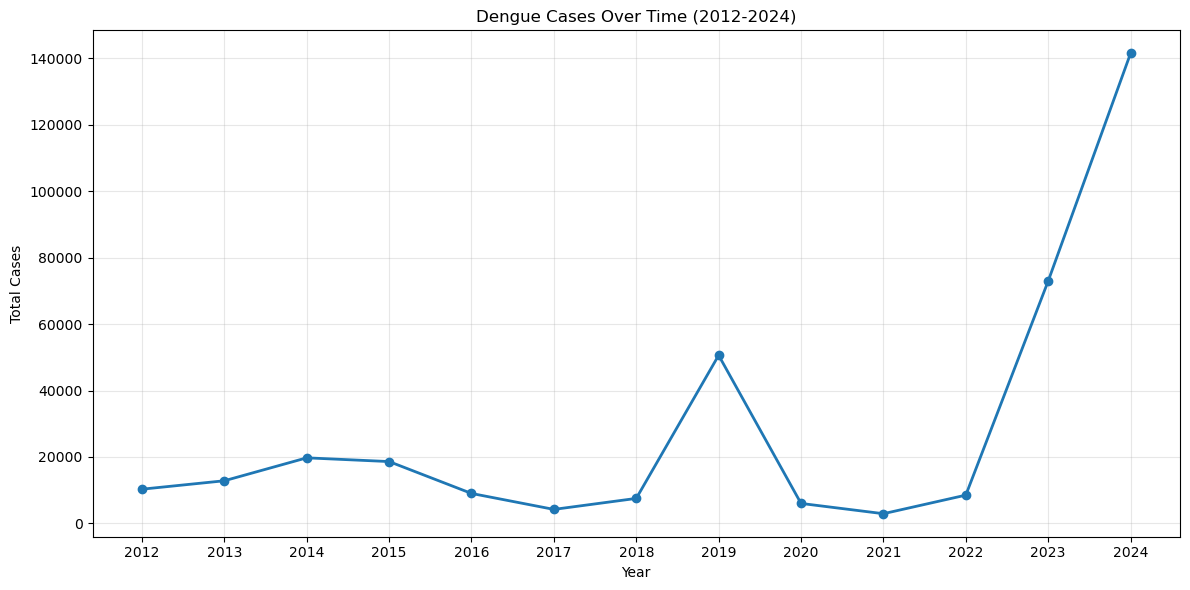

In [29]:
cases_year = year_totals.sort_values('year')
plt.figure(figsize=(12, 6))
plt.plot(cases_year['year'], cases_year['total_cases'], marker='o', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.title('Dengue Cases Over Time (2012-2024)')
plt.xticks(cases_year['year'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
From 2012 to 2022, reported dengue cases remained below 20,000 cases per year, except for 2019, when cases increased sharply to more than 40,000. A much larger increase appears in 2023 and 2024, with 2024 reaching the highest value in the period. This large spike affects the scale of the graph and makes earlier yearly variation harder to see. For this reason, a second graph excluding 2023 and 2024 can help examine the pre-spike pattern more clearly.

In [163]:
municipalities_grouped_year = year_municipality.groupby('year')
top10_each_year= municipalities_grouped_year.apply(
    lambda group: group.sort_values('total_cases', ascending=False).head(10)
)
top10_each_year = top10_each_year.reset_index(drop=False)
top10_each_year = top10_each_year.drop(columns="level_1")

top10_frequency = (
    top10_each_year["municipality"]
    .value_counts()
    .reset_index()
)

top10_frequency.columns = [
    "municipality",
    "years_in_top_10"
]
top10_frequency 

,municipality,years_in_top_10
0,COATEPEQUE,12
1,GUATEMALA,10
2,ZACAPA,9
3,JUTIAPA,7
4,PUERTO BARRIOS,7
5,ANTIGUA GUATEMALA,7
6,ESCUINTLA,6
7,MIXCO,6
8,SALAMÁ,5
9,AMATITLÁN,4


Although only 47 of the 325 municipalities (14%) appeared in the annual Top 10 at least once during the study period, these municipalities included several persistent high-burden locations. Coatepeque appeared in the annual Top 10 during 12 of the 13 years analyzed, followed by Guatemala (10 years) and Zacapa (9 years). Together with the finding that the Top 10 municipalities accounted for 34.5% of all reported dengue cases, these results suggest that dengue burden was geographically concentrated in a relatively small subset of municipalities rather than being evenly distributed across Guatemala.

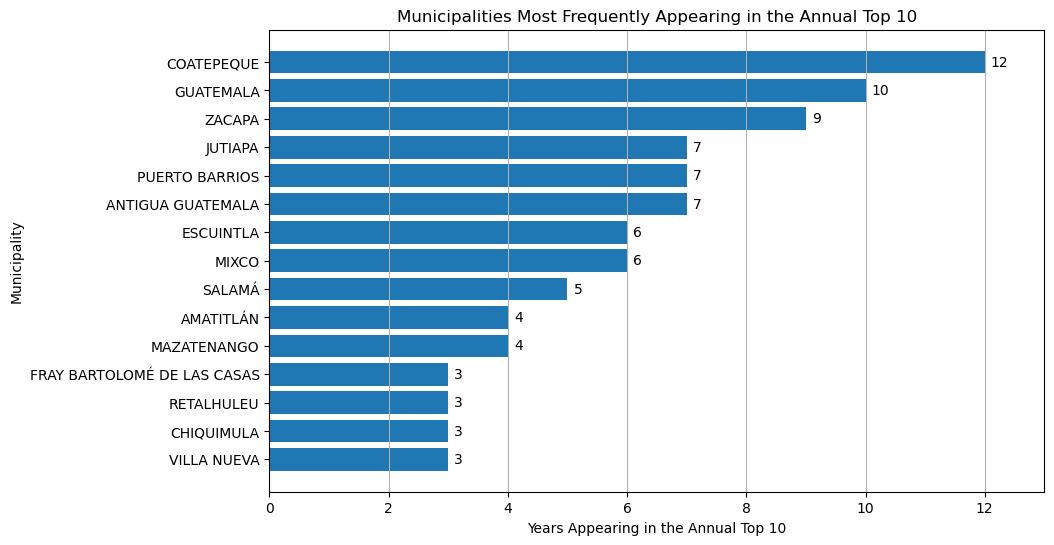

In [184]:
top15 = top10_frequency.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top15["municipality"],
    top15["years_in_top_10"]
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left"
    )

ax.set_xlabel("Years Appearing in the Annual Top 10")
ax.set_ylabel("Municipality")
ax.set_title("Municipalities Most Frequently Appearing in the Annual Top 10")

ax.grid(
    axis="x",
    alpha=1
)
ax.set_xlim(0, 13)

ax.invert_yaxis()

## Annual Trend Before 2023

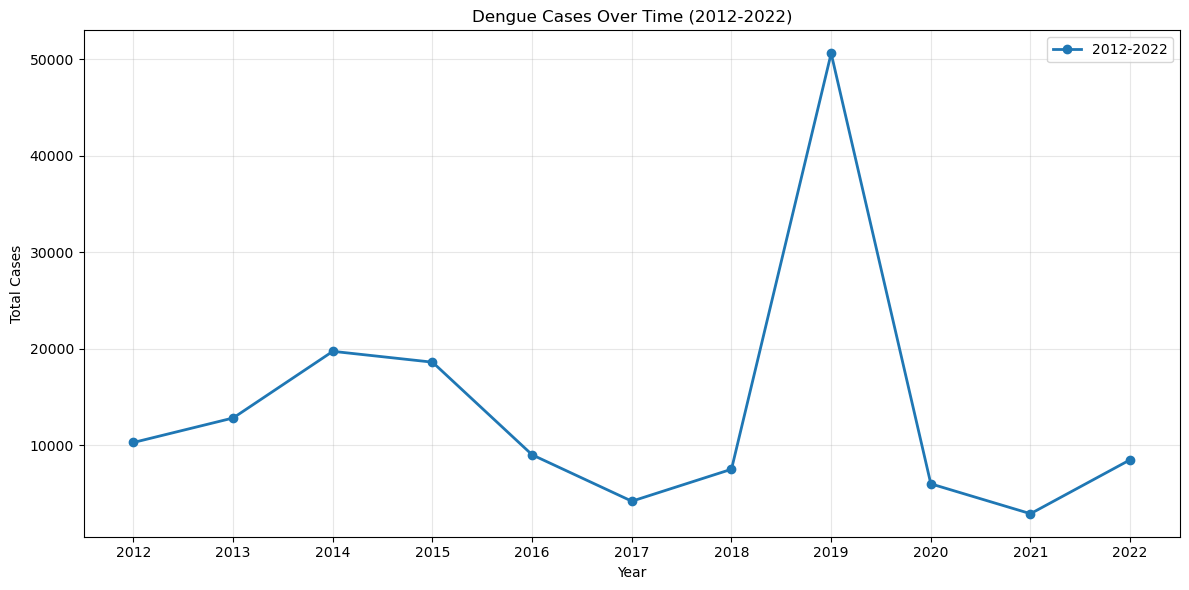

In [30]:
trend_before_2023 = year_totals[year_totals['year'] < 2023]
plt.figure(figsize=(12, 6))
plt.plot(trend_before_2023['year'], trend_before_2023['total_cases'], marker='o', linewidth=2, label='2012-2022')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.title('Dengue Cases Over Time (2012-2022)')
plt.xticks(trend_before_2023['year'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
In 2019, there was a relatively large spike of dengue cases compared to the years prior. From 2012 to 2014, a rise of cases is observed. After that, there was a progressive decline with its lowest number in 2017 followed by a slight increase before the 2019 spike. After 2019, a rapid decrease followed with the number of dengue cases returning to levels prior to 2019 below 20000 cases.

## Distribution of Cases by Municipality

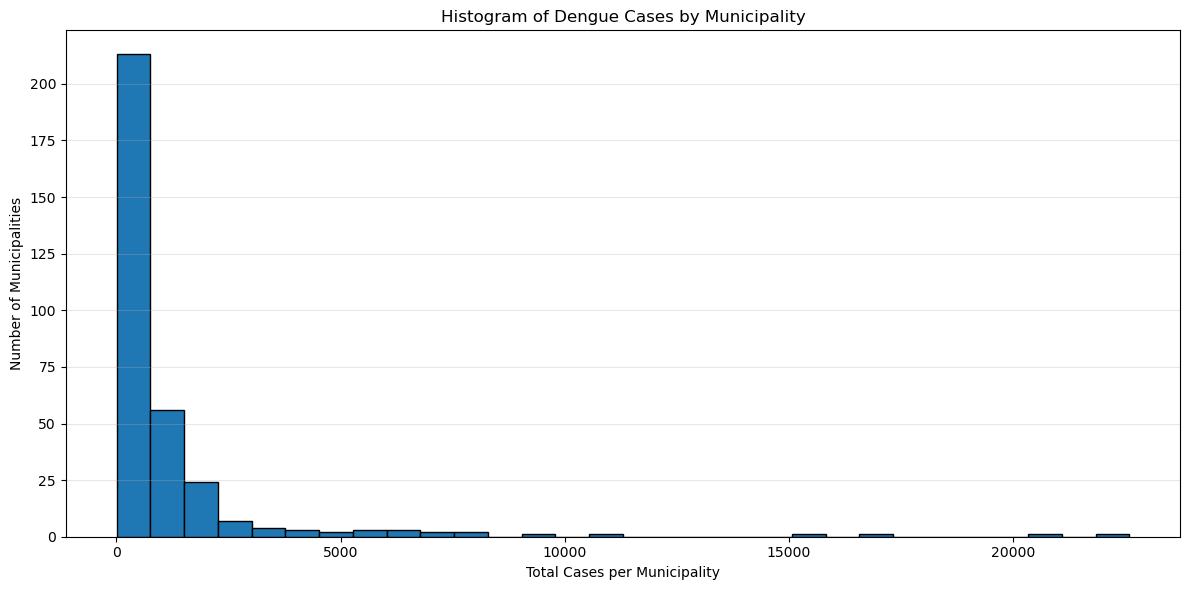

In [31]:
plt.figure(figsize=(12, 6))
plt.hist(municipality['total_cases'], bins=30, edgecolor='black')
plt.xlabel('Total Cases per Municipality')
plt.ylabel('Number of Municipalities')
plt.title('Histogram of Dengue Cases by Municipality')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This histogram shows a strongly right-skewed distribution of dengue cases across municipalities. Most municipalities accumulated relatively low numbers of cases during the study period, while a small number reported substantially higher totals. This pattern is consistent with the descriptive statistics, where the mean number of cases (1,122) exceeds the median (404), suggesting that a few municipalities with very high case counts pull the average upward.


## Top 10 Municipalities by Accumulated Cases (2012-2024)

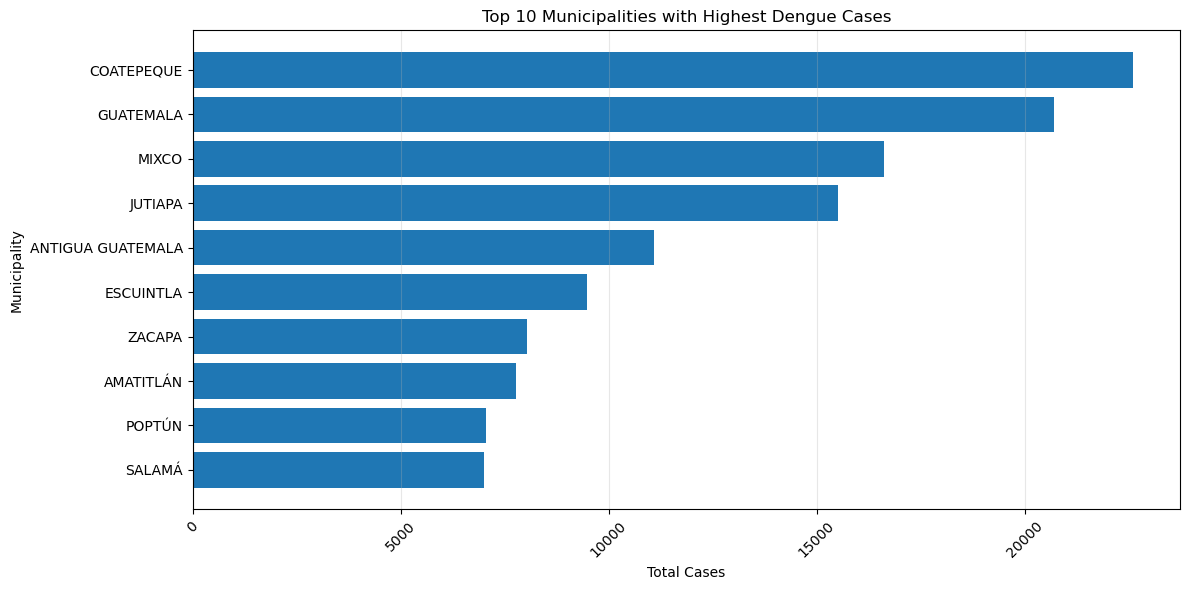

In [32]:
top_municipalities = municipality.groupby('municipality')['total_cases'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_municipalities.index, top_municipalities.values)
plt.xlabel('Total Cases')
plt.ylabel('Municipality')
plt.title('Top 10 Municipalities with Highest Dengue Cases')
plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()  # Invert y-axis to have the highest cases on top
plt.tight_layout()
plt.show()

### Interpretation
The gradual decrease in dengue cases among the top 10 municipalities suggests that several municipalities contribute substantially to the national dengue burden, rather than the burden being concentrated in one or only a few municipalities.

## Persistent and Peak Dengue Burden by Municipality (2012–2024)

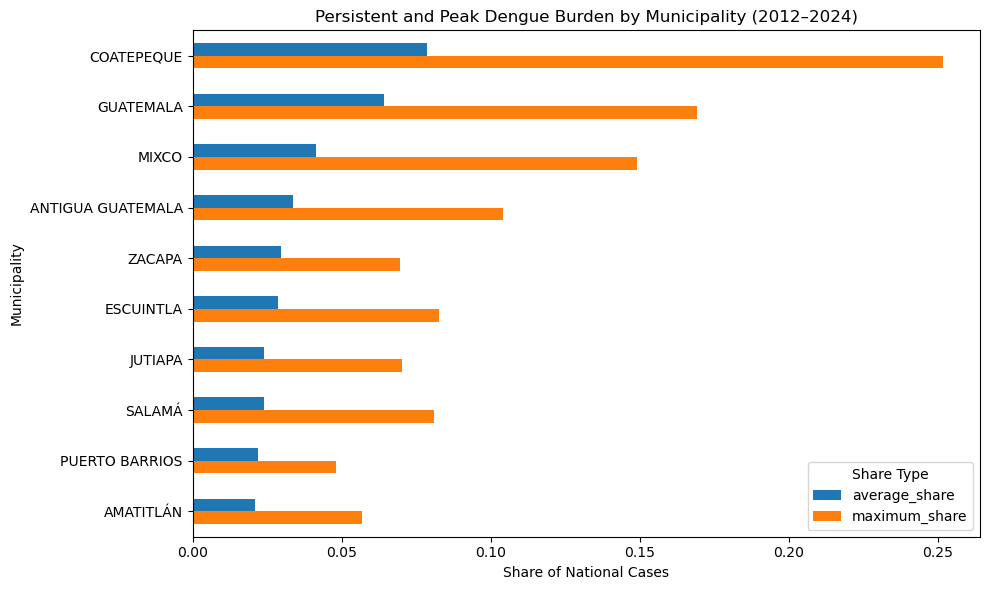

In [33]:
year_municipality_renamed = year_municipality.rename(
    columns={"total_cases": "municipality_cases"}
)
year_totals_renamed = year_totals.rename(
    columns={"total_cases": "national_cases"}
)
municipality_national_cases = pd.merge(year_municipality_renamed, year_totals_renamed, on="year")
municipality_national_cases['municipality_share'] = municipality_national_cases['municipality_cases'] / municipality_national_cases['national_cases']
persistent_driven_burden = municipality_national_cases.groupby("municipality")["municipality_share"].agg(
    average_share="mean",
    maximum_share="max"
).reset_index()
municipality_top10_persistent_burden = persistent_driven_burden.sort_values("average_share", ascending=False).head(10)
municipality_top10_persistent_burden.plot(
    x="municipality",
    y=["average_share", "maximum_share"],
    kind="barh",
    figsize=(10, 6)
)
plt.title("Persistent and Peak Dengue Burden by Municipality (2012–2024)")
plt.xlabel("Share of National Cases")
plt.ylabel("Municipality")
plt.legend(title="Share Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusions
1. Dengue cases stayed relatively low throughout 2012 to 2022, with one major spike in 2019 and one extreme outbreak period in 2023-2024.
2. Dengue cases are unevenly distributed across municipalities, with a relatively small subset accounting for a disproportionately large share of reported cases.
3. The top 10 municipalities show that several municipalities contribute to the high number of dengue cases throughout 2012-2024. The bars decreased gradually rather than dropping sharply.
4. Dengue cases fluctuate over time, with top municipalities having persistent contribution and peak-year fluctuations, and a few contributing substantially to the average burden.

### Interpretation
The maximum share is higher than the average share for all top municipalities, suggesting that dengue burden fluctuates substantially over time. However, municipalities such as Coatepeque and Guatemala also maintain relatively high average shares, indicating persistent contribution in addition to outbreak-year peaks.

## Conclusions
1. Dengue cases stayed relatively low throughout 2012 to 2022, with one major spike in 2019 and one extreme outbreak period in 2023-2024.
2. Dengue cases are unevenly distributed across municipalities, with a relatively small subset accounting for a disproportionately large share of reported cases.
3. The top 10 municipalities show that several municipalities contribute to the high number of dengue cases throughout 2012-2024. The bars decreased gradually rather than dropping sharply.
4. Dengue cases fluctuate over time, with top municipalities having persistent contribution and peak-year fluctuations, and a few contributing substantially to the average burden.